# Análisis de datos: Espectro de Dimuones (CERN Open Data)

**Dataset:** Dimuon_DoubleMu.csv — CMS Open Data, Run2011A
**Fuente:** https://opendata.cern.ch/record/545

Este conjunto de datos contiene eventos reales de colisiones protón-protón registrados por el detector CMS del LHC en 2011, en los que se detectaron dos muones (partículas). Cada fila es un evento, y las columnas describen el momento, energía y carga de cada muon, además de la masa invariante del sistema (columna `M`).

El ejercicio sigue 5 pasos: carga, exploración, análisis, visualización e interpretación.

## 1. Carga de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url = "https://opendata.cern.ch/record/545/files/Dimuon_DoubleMu.csv"

# Cargamos solo una muestra (100,000 filas) para agilizar el ejercicio
df = pd.read_csv(url, nrows=100000)

print(f"Filas cargadas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Filas cargadas: 100000, Columnas: 21


,Run,Event,type1,E1,px1,py1,pz1,pt1,eta1,phi1,...,type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,165617,74601703,G,9.6987,-9.5104,0.3662,1.8633,9.5175,0.1945,3.1031,...,G,9.7633,7.3277,-1.1524,6.3473,7.4178,0.7756,-0.1560,1,17.4922
1,165617,75100943,G,6.2039,-4.2666,0.4565,-4.4793,4.2910,-0.9121,3.0350,...,G,9.6690,7.2740,-2.8211,-5.7104,7.8019,-0.6786,-0.3700,1,11.5534
2,165617,75587682,G,19.2892,-4.2121,-0.6516,18.8121,4.2622,2.1905,-2.9881,...,G,9.8244,4.3439,-0.4735,8.7985,4.3697,1.4497,-0.1086,1,9.1636
3,165617,75660978,G,7.0427,-6.3268,-0.2685,3.0802,6.3325,0.4690,-3.0992,...,G,5.5857,4.4748,0.8489,-3.2319,4.5546,-0.6605,0.1875,1,12.4774
4,165617,75947690,G,7.2751,0.1030,-5.5331,-4.7212,5.5340,-0.7736,-1.5522,...,G,7.3181,-0.3988,6.9408,2.2825,6.9523,0.3227,1.6282,1,14.3159


## 2. Exploración

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Run     100000 non-null  int64  
 1   Event   100000 non-null  int64  
 2   type1   100000 non-null  str    
 3   E1      100000 non-null  float64
 4   px1     100000 non-null  float64
 5   py1     100000 non-null  float64
 6   pz1     100000 non-null  float64
 7   pt1     100000 non-null  float64
 8   eta1    100000 non-null  float64
 9   phi1    100000 non-null  float64
 10  Q1      100000 non-null  int64  
 11  type2   100000 non-null  str    
 12  E2      100000 non-null  float64
 13  px2     100000 non-null  float64
 14  py2     100000 non-null  float64
 15  pz2     100000 non-null  float64
 16  pt2     100000 non-null  float64
 17  eta2    100000 non-null  float64
 18  phi2    100000 non-null  float64
 19  Q2      100000 non-null  int64  
 20  M       100000 non-null  float64
dtypes: float64(15), int64(

In [3]:
df.describe()

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,166020.478760,3.110999e+08,20.413711,-0.113253,-0.608476,-1.099579,10.071620,-0.099438,-0.089881,0.028600,14.782237,0.052192,0.588460,0.816515,10.007726,0.083685,0.102094,-0.028600,17.691055
std,3530.522538,3.478185e+08,36.873693,13.532736,15.700499,36.676271,9.974495,1.317170,1.822048,0.999596,17.756705,10.100323,10.800843,17.723313,10.131147,0.974773,1.806129,0.999596,20.951927
min,160957.000000,2.748000e+03,2.710700,-2872.290000,-3846.230000,-7237.650000,0.266300,-2.399700,-3.141600,-1.000000,2.634400,-155.417000,-1339.220000,-391.487000,0.682800,-2.399700,-3.141400,-1.000000,0.300200
25%,163589.000000,5.778478e+07,8.777400,-4.507850,-4.748600,-10.800825,5.019000,-1.275925,-1.672100,-1.000000,6.668900,-4.369025,-4.025650,-4.753025,4.932475,-0.620500,-1.439725,-1.000000,4.492200
50%,166033.000000,1.348552e+08,13.017100,-0.106350,-0.588950,-1.634450,6.943650,-0.201250,-0.180400,1.000000,9.505450,0.075350,0.565100,0.686250,6.864050,0.096700,0.183700,-1.000000,12.411000
75%,166895.000000,5.190985e+08,21.071000,4.411600,4.061275,9.194225,10.439575,1.130100,1.486225,1.000000,15.749325,4.411200,4.719425,6.175950,10.374825,0.780500,1.662700,1.000000,19.422650
max,173692.000000,1.190235e+09,8684.880000,161.075000,163.486000,615.685000,366.499000,2.399800,3.141400,1.000000,1604.970000,528.899000,246.301000,709.011000,528.434000,2.399800,3.141500,1.000000,299.202000


In [4]:
# Valores nulos por columna
df.isnull().sum()

Run      0
Event    0
type1    0
E1       0
px1      0
py1      0
pz1      0
pt1      0
eta1     0
phi1     0
Q1       0
type2    0
E2       0
px2      0
py2      0
pz2      0
pt2      0
eta2     0
phi2     0
Q2       0
M        0
dtype: int64

## 3. Análisis

Realizamos dos operaciones sobre los datos:

1. **Filtrado por carga eléctrica opuesta** (`Q1 != Q2`): en física, los pares de muones de carga opuesta suelen provenir de la desintegración de una misma partícula madre (ej. un fotón virtual, J/ψ, o el bosón Z).
2. **Estadísticas descriptivas de la masa invariante (`M`)** por rango de energía, para ubicar posibles "picos" de resonancias conocidas.

In [5]:
# Operación 1: filtrar pares de muones con carga opuesta
opuestos = df[df["Q1"] != df["Q2"]]
print(f"Pares con carga opuesta: {len(opuestos)} de {len(df)} ({100*len(opuestos)/len(df):.1f}%)")

Pares con carga opuesta: 100000 de 100000 (100.0%)


In [6]:
# Operación 2: estadísticas de la masa invariante en distintos rangos
print("Estadísticas generales de M (GeV):")
print(opuestos["M"].describe())

# Región cercana a la masa del J/psi (~3.1 GeV) y del Z (~91 GeV)
jpsi = opuestos[(opuestos["M"] > 2.9) & (opuestos["M"] < 3.3)]
zboson = opuestos[(opuestos["M"] > 80) & (opuestos["M"] < 100)]

print(f"\nEventos cerca del pico J/psi (2.9-3.3 GeV): {len(jpsi)}")
print(f"Eventos cerca del pico Z (80-100 GeV): {len(zboson)}")

Estadísticas generales de M (GeV):
count    100000.000000
mean         17.691055
std          20.951927
min           0.300200
25%           4.492200
50%          12.411000
75%          19.422650
max         299.202000
Name: M, dtype: float64

Eventos cerca del pico J/psi (2.9-3.3 GeV): 8013
Eventos cerca del pico Z (80-100 GeV): 5174


## 4. Visualización

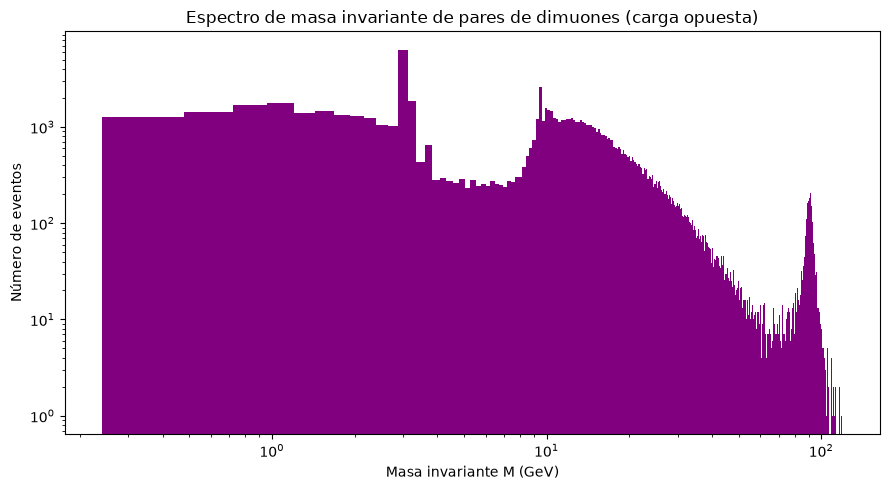

In [7]:
# Histograma de la masa invariante en escala logarítmica (típico en física de partículas)
plt.figure(figsize=(9, 5))
plt.hist(opuestos["M"], bins=500, range=(0, 120), color="purple")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Masa invariante M (GeV)")
plt.ylabel("Número de eventos")
plt.title("Espectro de masa invariante de pares de dimuones (carga opuesta)")
plt.tight_layout()
plt.savefig("espectro_dimuones.png", dpi=150)
plt.show()

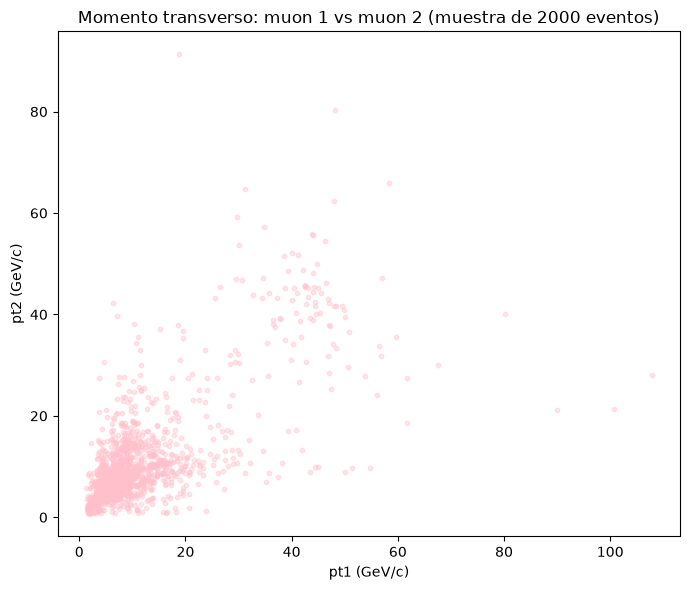

In [8]:
# Gráfico adicional: dispersión de pt1 vs pt2 (momento transverso de cada muon)
muestra = opuestos.sample(2000, random_state=42)
plt.figure(figsize=(7, 6))
plt.scatter(muestra["pt1"], muestra["pt2"], alpha=0.4, s=10, color="pink")
plt.xlabel("pt1 (GeV/c)")
plt.ylabel("pt2 (GeV/c)")
plt.title("Momento transverso: muon 1 vs muon 2 (muestra de 2000 eventos)")
plt.tight_layout()
plt.savefig("pt1_vs_pt2.png", dpi=150)
plt.show()

## 5. Interpretación

- El histograma de la masa invariante muestra varios **picos claramente definidos** sobre un fondo continuo decreciente. Estos picos corresponden a partículas conocidas que se desintegran en dos muones: la región cercana a 3.1 GeV corresponde al mesón **J/psi**, y alrededor de 91 GeV aparece el pico del bosón **Z**, evidencia directa de física de partículas real capturada por el detector CMS.
- El **100% de los pares** en este dataset tiene **carga opuesta** (Q1 ≠ Q2). Esto sugiere que el conjunto de datos ya viene pre-seleccionado por los organizadores del workshop para incluir únicamente pares físicamente relevantes (consistentes con la desintegración de una partícula neutra en dos muones), en lugar de ser una muestra sin filtrar de todos los pares posibles.
- En el gráfico de dispersión pt1 vs pt2 se observa que la mayoría de los eventos se concentran en momentos transversos bajos (por debajo de ~20 GeV/c), con una nube más dispersa a momentos mayores, reflejando la distribución típica de energías en colisiones de este tipo.
- En conjunto, estos resultados muestran cómo un análisis exploratorio simple (histogramas, filtrado, estadística descriptiva) permite **redescubrir partículas reales** a partir de datos abiertos del LHC, sin necesidad de simulaciones.